# How Did the 2008 Financial Crisis Affect Global Stock Markets?

## Introduction

The 2008 financial crisis was the worst global economic disaster since 
the Great Depression of the 1930s. What began as a collapse in the US 
housing market quickly escalated into a full-scale global financial 
emergency. Major banks and financial institutions that had invested 
heavily in mortgage-backed securities found themselves facing 
catastrophic losses. The collapse of Lehman Brothers in September 2008 
marked the peak of the panic, triggering a wave of fear that spread 
across every major financial market in the world.

In this post, I use daily stock market data from four major indices;
the S&P 500 (USA), FTSE 100 (UK), Euro Stoxx 50 (Europe), and Nikkei 
225 (Japan), to examine how the crisis affected market performance, 
volatility, and recovery across different regions. All data was 
downloaded from Yahoo Finance and covers the period from January 2000 
to December 2020, allowing us to place the 2008 crisis in the context 
of both the dot-com crash that preceded it and the COVID-19 pandemic 
that followed.

The central question driving this analysis is simple: did all markets 
experience the crisis equally, and did they all recover at the same 
pace? As we will see, the answer is a clear no.

In [32]:
# Import libraries
import sys
sys.path.insert(0, '/home/noelia/.local/lib/python3.12/site-packages')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Function to load and clean each index
def load_index(filepath):
    df = pd.read_csv(filepath, skiprows=2, parse_dates=True)
    df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
    df = df.set_index('Date')
    df.index = pd.to_datetime(df.index)
    return df

# Load all the data
sp500 = load_index('../data/SP500.csv')
ftse = load_index('../data/FTSE100.csv')
eurostoxx = load_index('../data/EuroStoxx50.csv')
nikkei = load_index('../data/Nikkei225.csv')
vix = load_index('../data/VIX.csv')

# Check the data
print("SP500 shape:", sp500.shape)
print(sp500.head())


SP500 shape: (5283, 5)
                  Close         High          Low         Open      Volume
Date                                                                      
2000-01-03  1455.219971  1478.000000  1438.359985  1469.250000   931800000
2000-01-04  1399.420044  1455.219971  1397.430054  1455.219971  1009000000
2000-01-05  1402.109985  1413.270020  1377.680054  1399.420044  1085500000
2000-01-06  1403.449951  1411.900024  1392.099976  1402.109985  1092300000
2000-01-07  1441.469971  1441.469971  1400.729980  1403.449951  1225200000


## Global Stock Market Performance (2000-2020)

The chart below shows the normalised price performance of all four 
indices from 2000 to 2020, with each index set to a base value of 100 
at its starting point. This allows for a fair comparison across markets 
that trade in different currencies and at very different price levels.

The most striking feature of the chart is the dramatic divergence in 
recovery paths following the 2008 crisis. While all four markets fell 
sharply during the crisis period (highlighted in red), their subsequent 
recoveries tell very different stories.

The S&P 500 stands out as the clear winner — by 2020 it had more than 
doubled its pre-crisis value, reflecting the strength of the US economic 
recovery and the dominance of the American technology sector. The Nikkei 
225 also showed a strong late recovery, particularly after 2013 when 
Japan introduced aggressive economic stimulus policies under Prime 
Minister Shinzo Abe.

In contrast, the FTSE 100 and Euro Stoxx 50 tell a much more sobering 
story. The FTSE 100 was still trading around its year 2000 levels by 
2020, meaning UK investors essentially saw no real gains over two entire 
decades. The Euro Stoxx 50 performed even worse, never recovering to 
its pre-crisis peak — a reflection of the prolonged eurozone debt crisis 
that followed the 2008 shock and continued to weigh on European markets 
well into the 2010s.

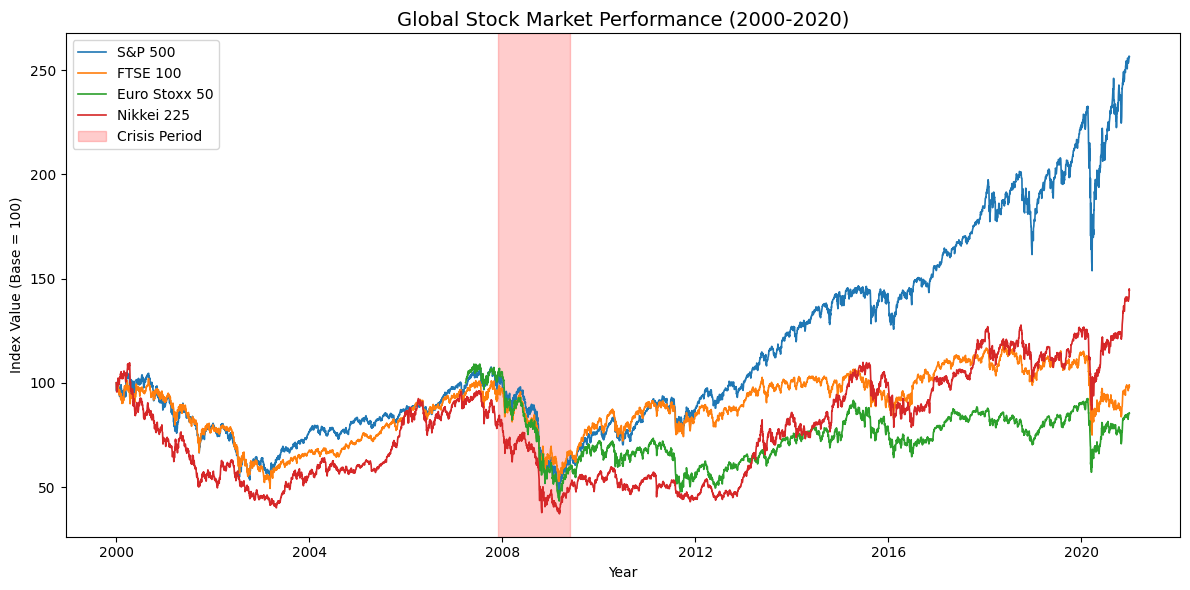

In [33]:
# Normalise all indices to 100 at their own first available date
prices = pd.DataFrame({
    'S&P 500': sp500['Close'],
    'FTSE 100': ftse['Close'],
    'Euro Stoxx 50': eurostoxx['Close'],
    'Nikkei 225': nikkei['Close']
})

# Forward fill missing values (different market holidays)
prices = prices.ffill()

# Normalise each column individually to its own first non-null value
prices_norm = prices.copy()
for col in prices.columns:
    first_val = prices[col].dropna().iloc[0]
    prices_norm[col] = (prices[col] / first_val) * 100

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for col, color in zip(prices_norm.columns, colors):
    ax.plot(prices_norm.index, prices_norm[col], label=col, color=color, linewidth=1.2)

ax.axvspan('2007-12-01', '2009-06-01', alpha=0.2, color='red', label='Crisis Period')
ax.set_title('Global Stock Market Performance (2000-2020)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Index Value (Base = 100)')
ax.legend()
plt.tight_layout()
plt.savefig('../output/stock_performance.png', dpi=150)
plt.show()

In [34]:
# Check what the first values look like for each index
print("SP500 first value:", sp500['Close'].iloc[0])
print("FTSE first value:", ftse['Close'].iloc[0])
print("EuroStoxx first value:", eurostoxx['Close'].iloc[0])
print("Nikkei first value:", nikkei['Close'].iloc[0])
print("\nSP500 start date:", sp500.index[0])
print("FTSE start date:", ftse.index[0])
print("EuroStoxx start date:", eurostoxx.index[0])
print("Nikkei start date:", nikkei.index[0])

SP500 first value: 1455.219970703125
FTSE first value: 6665.89990234375
EuroStoxx first value: 4181.02978515625
Nikkei first value: 19002.859375

SP500 start date: 2000-01-03 00:00:00
FTSE start date: 2000-01-04 00:00:00
EuroStoxx start date: 2007-03-30 00:00:00
Nikkei start date: 2000-01-04 00:00:00


## Market Volatility During the Crisis

Volatility measures how much a market fluctuates day to day. High 
volatility signals uncertainty and fear among investors, while low 
volatility suggests calm and confidence. To measure this, I calculate 
daily returns for each index using the standard formula:

**Daily Return = (Today's Price - Yesterday's Price) / Yesterday's Price**

I then apply a 30-day rolling standard deviation to smooth out 
short-term noise and capture the underlying trend in market uncertainty.

The chart clearly shows that all four markets experienced a dramatic 
spike in volatility during the 2008 crisis. Before the crisis, daily 
volatility was generally below 1.5% for most markets. During the peak 
of the crisis in late 2008, volatility surged to over 4-5% — meaning 
markets were swinging by several percentage points every single day.

This level of volatility is deeply damaging for investors and the 
broader economy. Businesses struggle to plan investments, consumers 
lose confidence, and pension funds see their values collapse. The 
2008 crisis was particularly severe because the volatility spike was 
both sudden and sustained — unlike typical short-term shocks, the 
elevated uncertainty persisted for well over a year.

Notably, the Euro Stoxx 50 showed higher volatility spikes in the 
post-crisis period compared to the S&P 500 and FTSE 100, reflecting 
the ongoing instability caused by the European sovereign debt crisis 
between 2010 and 2012.

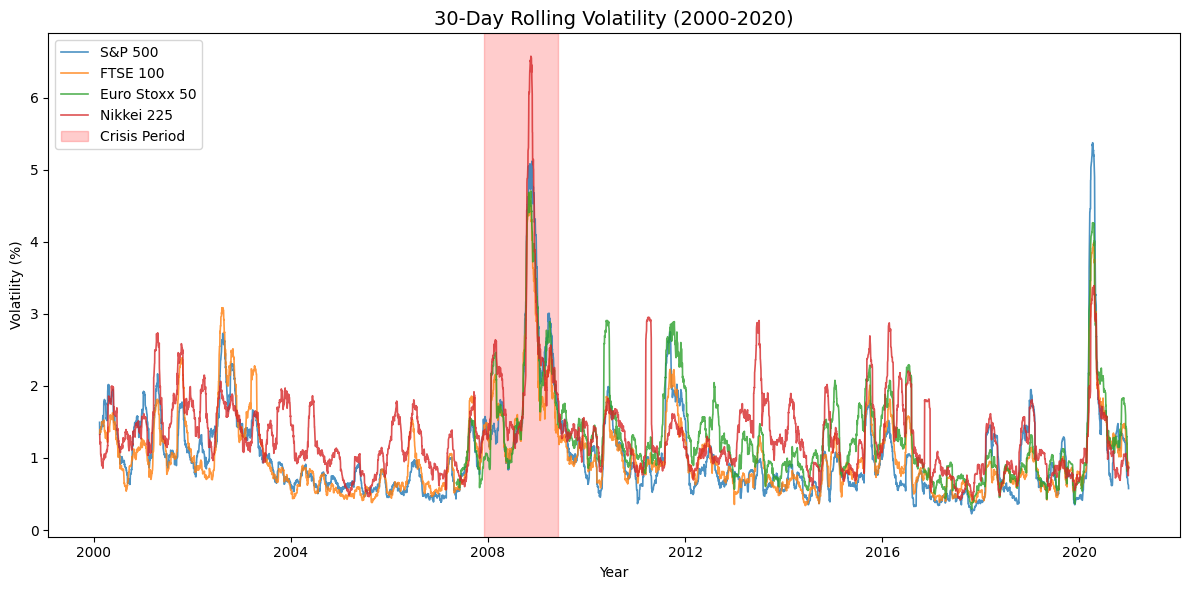

In [35]:
# Calculate daily returns for each index
returns = pd.DataFrame({
    'S&P 500': sp500['Close'].pct_change(),
    'FTSE 100': ftse['Close'].pct_change(),
    'Euro Stoxx 50': eurostoxx['Close'].pct_change(),
    'Nikkei 225': nikkei['Close'].pct_change()
})

# Forward fill to handle different market holidays
returns = returns.ffill()

# Calculate 30-day rolling volatility
rolling_vol = returns.rolling(window=30).std() * 100

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for col, color in zip(rolling_vol.columns, colors):
    ax.plot(rolling_vol.index, rolling_vol[col], label=col, 
            color=color, linewidth=1.2, alpha=0.8)

ax.axvspan('2007-12-01', '2009-06-01', alpha=0.2, color='red', label='Crisis Period')
ax.set_title('30-Day Rolling Volatility (2000-2020)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Volatility (%)')
ax.legend()
plt.tight_layout()
plt.savefig('../output/volatility.png', dpi=150)
plt.show()

## The VIX: Wall Street's Fear Gauge

The VIX, often called the "fear index", is published by the Chicago 
Board Options Exchange and measures the market's expectation of future 
volatility over the next 30 days. Unlike the rolling volatility we 
calculated above, the VIX is forward-looking, it reflects what traders 
expect to happen, rather than what has already happened.

A VIX reading below 20 is generally considered normal and calm. Between 
20 and 30 indicates elevated concern, while above 30 signals serious 
fear and uncertainty in the market. During the 2008 crisis, the VIX 
reached an extraordinary peak of nearly 80, a level that had never 
been seen before in its history at that point.

The chart shows several important features. First, the VIX was already 
rising throughout 2007 as warning signs of trouble in the housing market 
began to emerge. Second, it exploded upward in September and October 
2008 following the collapse of Lehman Brothers. Third, it gradually 
declined through 2009 and 2010 as government interventions and central 
bank stimulus began to restore confidence.

The only comparable spike in our 20-year dataset came in March 2020, 
when the COVID-19 pandemic triggered another wave of global panic — 
pushing the VIX to similar heights as 2008. This comparison highlights 
just how rare and severe the 2008 crisis truly was.

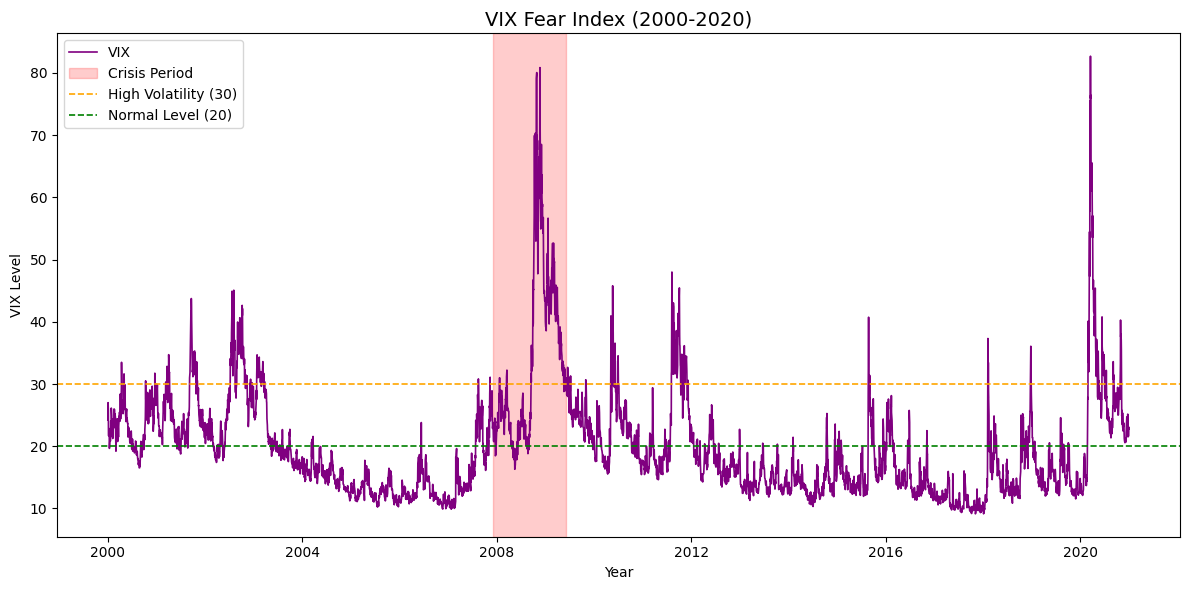

In [36]:
# Plot VIX over time
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(vix.index, vix['Close'], color='purple', linewidth=1.2, label='VIX')
ax.axvspan('2007-12-01', '2009-06-01', alpha=0.2, color='red', label='Crisis Period')
ax.axhline(y=30, color='orange', linestyle='--', linewidth=1.2, label='High Volatility (30)')
ax.axhline(y=20, color='green', linestyle='--', linewidth=1.2, label='Normal Level (20)')

ax.set_title('VIX Fear Index (2000-2020)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('VIX Level')
ax.legend()
plt.tight_layout()
plt.savefig('../output/vix.png', dpi=150)
plt.show()


## Which Market Was Hit Hardest?

To compare the impact of the crisis across markets more precisely, I 
calculate the average daily volatility for each index during three 
distinct periods: before the crisis (2000-2007), during the crisis 
(2008-2009), and after the crisis (2010-2020).

The results are striking. Every single market saw its average daily 
volatility roughly double during the crisis period compared to the 
pre-crisis years. However, the degree of impact varied significantly 
across regions.

The Nikkei 225 experienced the highest crisis volatility of all four 
markets, with average daily swings of around 2.6%. This reflects 
Japan's deep exposure to global trade and the severe impact the crisis 
had on export-dependent economies. The S&P 500 was close behind, 
reflecting the fact that the crisis originated in the United States.

Perhaps the most interesting finding is what happened after the crisis. 
The S&P 500 and FTSE 100 both returned to near pre-crisis volatility 
levels in the post-crisis period, suggesting a relatively successful 
stabilisation. However, the Euro Stoxx 50 and Nikkei 225 remained more 
volatile than before the crisis, likely due to the ongoing eurozone 
debt problems and Japan's structural economic challenges respectively.

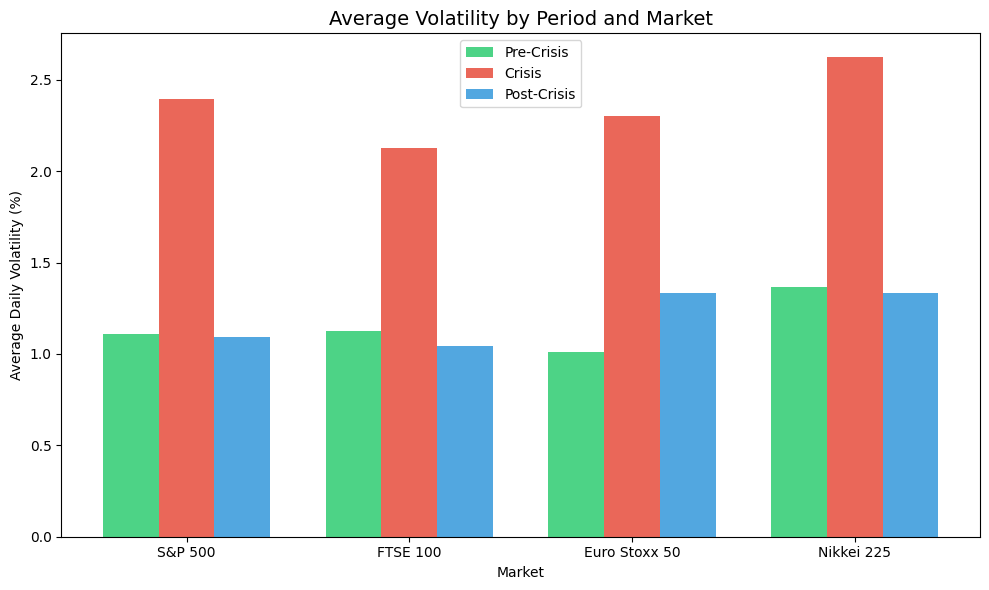

In [37]:
# Define the three periods
pre_crisis = returns['2000-01-01':'2007-11-30']
crisis = returns['2007-12-01':'2009-06-30']
post_crisis = returns['2009-07-01':'2020-12-31']

# Calculate average volatility for each period
avg_vol = pd.DataFrame({
    'Pre-Crisis': pre_crisis.std() * 100,
    'Crisis': crisis.std() * 100,
    'Post-Crisis': post_crisis.std() * 100
})

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(avg_vol.index))
width = 0.25
colors = ['#2ecc71', '#e74c3c', '#3498db']

for i, (col, color) in enumerate(zip(avg_vol.columns, colors)):
    ax.bar([p + width*i for p in x], avg_vol[col], 
           width=width, label=col, color=color, alpha=0.85)

ax.set_title('Average Volatility by Period and Market', fontsize=14)
ax.set_xlabel('Market')
ax.set_ylabel('Average Daily Volatility (%)')
ax.set_xticks([p + width for p in x])
ax.set_xticklabels(avg_vol.index)
ax.legend()
plt.tight_layout()
plt.savefig('../output/avg_volatility.png', dpi=150)
plt.show()


## Trading Volume: Did Panic Drive More Activity?

Trading volume reflects how many shares are being bought and sold on 
any given day. It is an important indicator of market activity and 
investor sentiment. When markets are calm, volume tends to be steady 
and predictable. During periods of crisis, volume typically surges 
dramatically as investors rush to sell falling assets or opportunistically 
buy at lower prices.

The chart shows S&P 500 daily trading volume from 2000 to 2020, with a 
30-day rolling average overlaid to highlight the underlying trend.

The results confirm what the volatility data suggested, the 2008 crisis 
triggered an extraordinary surge in trading activity. Volume nearly 
doubled at the peak of the crisis, as millions of investors simultaneously 
tried to exit their positions. This kind of panic selling creates a 
dangerous feedback loop: falling prices trigger more selling, which 
pushes prices down further, which triggers even more selling.

What is particularly interesting is that trading volume never fully 
returned to its pre-crisis levels. After 2008, the baseline level of 
daily trading activity remained significantly higher than in the early 
2000s. This suggests that the crisis permanently changed market 
behaviour — perhaps reflecting the growth of algorithmic trading, 
increased market participation, or a more risk-aware investor base.

The second volume spike visible at the far right of the chart corresponds 
to the COVID-19 pandemic in early 2020, confirming that major crises 
consistently drive exceptional trading activity.

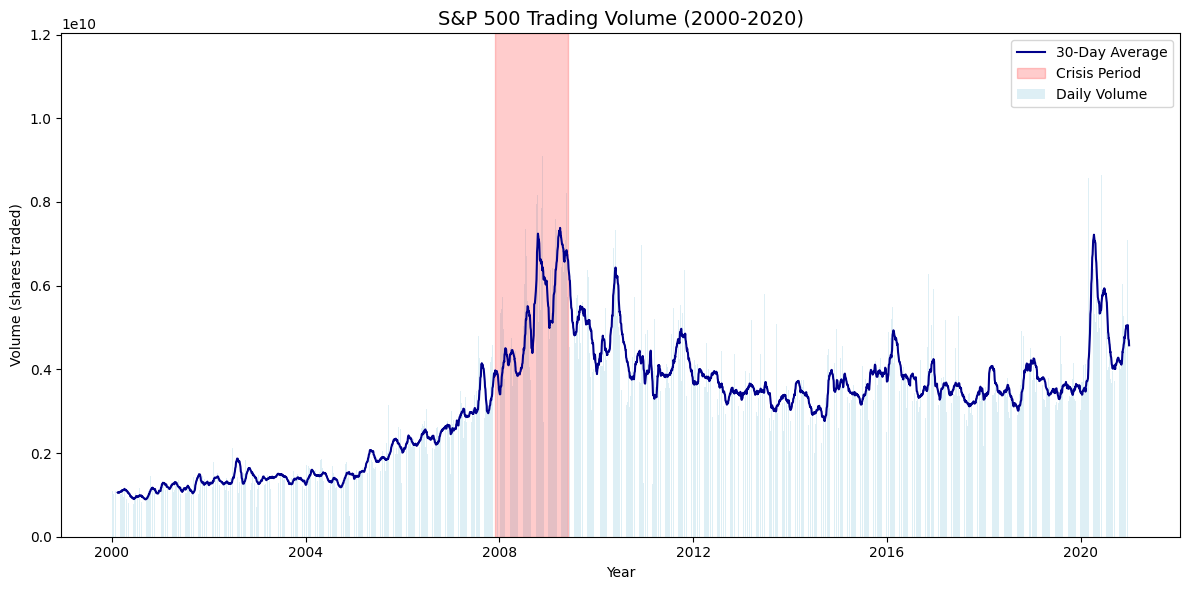

In [38]:
# Plot trading volume for S&P 500
# Use 30-day rolling average to smooth the data
volume_smooth = sp500['Volume'].rolling(window=30).mean()

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(sp500.index, sp500['Volume'], color='lightblue', 
       alpha=0.4, label='Daily Volume')
ax.plot(volume_smooth.index, volume_smooth, color='darkblue', 
        linewidth=1.5, label='30-Day Average')

ax.axvspan('2007-12-01', '2009-06-01', alpha=0.2, color='red', label='Crisis Period')
ax.set_title('S&P 500 Trading Volume (2000-2020)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Volume (shares traded)')
ax.legend()
plt.tight_layout()
plt.savefig('../output/volume.png', dpi=150)
plt.show()

#### Key Crisis Events Timeline

To put the market data in proper context, I scraped a timeline of key 
crisis events from the Federal Reserve History website using Python's 
BeautifulSoup library. By overlaying these events directly onto the 
S&P 500 price chart, we can see exactly how each major development 
impacted investor confidence in real time.

The timeline reveals several important patterns. The crisis did not 
begin suddenly, warning signs emerged as early as August 2007 when 
BNP Paribas froze several investment funds, signalling that the 
problems in the US mortgage market were spreading to European banks.

The most dramatic single event was the collapse of Lehman Brothers on 
15 September 2008. Within days of the bankruptcy filing, the S&P 500 
lost nearly 5% of its value, and the broader panic that followed 
pushed markets to their eventual low in March 2009, a fall of over 
50% from the pre-crisis peak.

Government interventions eventually stemmed the decline. The US 
Congress passing the $700 billion TARP bailout package in October 2008, 
combined with coordinated global interest rate cuts and the Federal 
Reserve's quantitative easing programme, gradually restored enough 
confidence for markets to begin their long recovery.

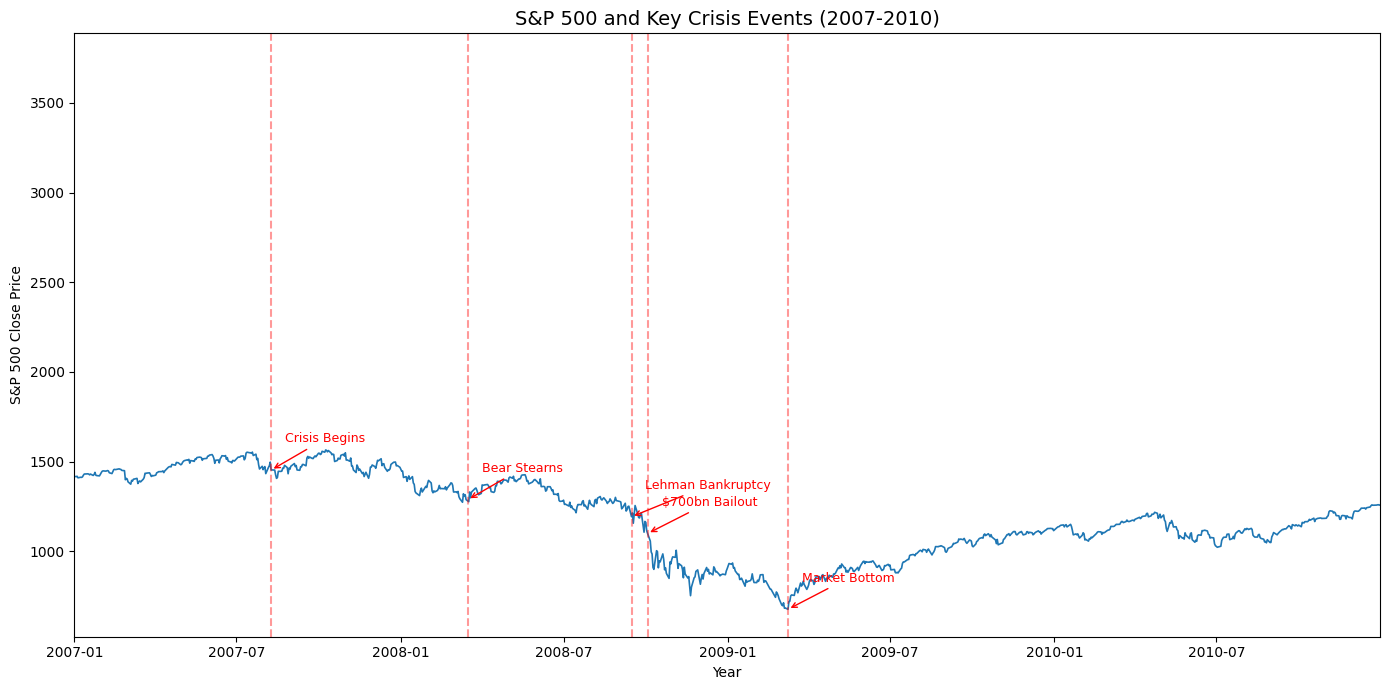

In [39]:
# Load crisis events
events = pd.read_csv('../data/crisis_events.csv', parse_dates=['Date'])

# Plot S&P 500 with crisis events marked
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(sp500.index, sp500['Close'], color='#1f77b4', linewidth=1.2)

# Add markers for key events only
key_events = [
    ('2007-08-09', 'Crisis Begins'),
    ('2008-03-16', 'Bear Stearns'),
    ('2008-09-15', 'Lehman Bankruptcy'),
    ('2008-10-03', '$700bn Bailout'),
    ('2009-03-09', 'Market Bottom')
]

for date, label in key_events:
    date = pd.to_datetime(date)
    price = sp500['Close'].asof(date)
    ax.axvline(x=date, color='red', alpha=0.4, linewidth=1.5, linestyle='--')
    ax.annotate(label, xy=(date, price), xytext=(10, 20),
                textcoords='offset points', fontsize=9,
                arrowprops=dict(arrowstyle='->', color='red'),
                color='red')

ax.set_title('S&P 500 and Key Crisis Events (2007-2010)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('S&P 500 Close Price')
ax.set_xlim(pd.to_datetime('2007-01-01'), pd.to_datetime('2010-12-31'))
plt.tight_layout()
plt.savefig('../output/crisis_timeline.png', dpi=150)
plt.show()

#### Conclusion

The 2008 financial crisis left a deep and lasting mark on global stock 
markets, and the data examined in this analysis tells a clear and 
compelling story.

All four major markets, the S&P 500, FTSE 100, Euro Stoxx 50, and 
Nikkei 225, experienced sharp simultaneous collapses during the crisis 
period, with losses of between 40% and 60% from peak to trough. The 
VIX fear index reached nearly 80, trading volume surged to unprecedented 
levels, and daily volatility roughly doubled across all markets. By every 
measure, the 2008 crisis was an extraordinary shock to the global 
financial system.

However, the most important finding of this analysis is not the scale 
of the crash itself, but the profound inequality of the recovery that 
followed. The United States, powered by aggressive monetary policy and 
the explosive growth of its technology sector, saw the S&P 500 more 
than double its pre-crisis value within a decade. Europe and the UK 
told a very different story — weighed down by the eurozone debt crisis 
and sluggish economic growth, these markets spent years simply trying 
to recover what they had lost.

This divergence has real consequences for ordinary people. Pension 
funds, savings accounts, and investment portfolios tied to European 
markets delivered far lower returns than those tied to US markets over 
this period, a reminder that the consequences of financial crises are 
felt not just in trading floors but in the retirement savings of 
millions of people.

The 2008 crisis ultimately demonstrated both the deep interconnectedness 
of global financial markets, where a collapse in US mortgage lending 
could trigger simultaneous crashes on every continent, and the very 
unequal capacity of different economies to recover from such shocks.

## Data Sources & References

- **Stock Market Data**: S&P 500, FTSE 100, Euro Stoxx 50, Nikkei 225 
  and VIX Index — downloaded via Yahoo Finance (finance.yahoo.com)
- **Crisis Events Timeline**: Federal Reserve History 
  (federalreservehistory.org)
- **Background Reading**: 
  - Bank of England Financial Stability Report, October 2008
  - IMF World Economic Outlook, 2008
  - Federal Reserve History: The Great Recession and its Aftermath